# Level 5 — Data Mining Challenge: *The 1,000-Pick*

**규칙**: Set B (이미지 + 라벨 공개) 에서 **최대 1,000장** 을 선택하여 학습 셋에 추가하고, best 모델을 다시 학습하세요.

> **Set B 의 라벨이 공개되어 있다는 점에 주의**하세요. 본 Level 의 평가 본질은 "*주어진 풀에서 어떤 1,000장이 가장 가치 있는가*" — 즉, 라벨을 알고 있다고 가정한 상태에서의 효율적인 부분집합 선택입니다.

**본 PA에서 가장 큰 비중 (25%)** 을 차지하는 Level 입니다. 어떤 *알고리즘* 으로 1,000장을 골랐는지 — 그 *근거* — 가 변별력의 본진입니다. Curation Report 로 정리합니다.

채점 메트릭:
$$\text{DI} = \frac{\text{Avg-MF1}(\text{본인 picks}) - \text{Avg-MF1}(\text{random picks})}{\text{Avg-MF1}(\text{random picks})}$$

## 검토해 볼 만한 전략

| 전략 | 핵심 아이디어 | Set B 라벨 활용 |
|---|---|---|
| 클래스 균형 (Class Balancing) | Set A 에서 부족한 속성 클래스 (foggy / dawn-dusk 등) 를 채워 넣음 | ✅ 라벨로 직접 필터링 |
| Hard Example Mining | base 모델의 confidence 가 낮은 / 예측이 라벨과 다른 이미지를 우선 선택 | ✅ 모델 예측 vs 정답 비교 |
| 다양성 (Core-Set) | Set B 의 feature space 를 가장 잘 커버하는 부분집합 선택 (k-center / clustering) | 라벨 무관 |
| 결합 커버리지 | 속성 *조합* 의 균형을 맞춤 — 예: (snowy & night), (rainy & residential) | ✅ 라벨로 조합 카운트 |
| Loss 기반 | Set B 이미지에 대한 학습 직전 loss 가 큰 샘플 우선 | ✅ 라벨 필요 |

위 전략들을 결합/응용/대체할 수 있습니다. **Curation Report 에 본인의 의사결정 근거를 명확히 기술** 하세요.

**산출물**: `level5_picks.json` — 선택한 image_id 리스트 (이미지별 메타데이터 포함 가능).

In [1]:
import os
import sys

repo_name = "2026-HYU-AUE8088-PA2"
repo_path = f"/content/{repo_name}"
repo_url = "https://github.com/Jieunn-Kim/2026-HYU-AUE8088-PA2.git"

if not os.path.exists(repo_path):
    !git clone {repo_url} {repo_path}
else:
    %cd {repo_path}
    !git pull origin main

%cd {repo_path}

if repo_path not in sys.path:
    sys.path.insert(0, repo_path)

print("Current directory:", os.getcwd())

%load_ext autoreload
%autoreload 2

# 의존성 설치 (이미 설치된 패키지는 빠르게 skip)
!pip install -q -r requirements.txt

Cloning into '/content/2026-HYU-AUE8088-PA2'...
remote: Enumerating objects: 72, done.
remote: Counting objects: 100% (37/37), done.
remote: Compressing objects: 100% (31/31), done.
Receiving objects: 100% (72/72), 2.02 MiB | 6.16 MiB/s, done.
remote: Total 72 (delta 23), reused 6 (delta 6), pack-reused 35 (from 1)
Resolving deltas: 100% (28/28), done.
/content/2026-HYU-AUE8088-PA2
Current directory: /content/2026-HYU-AUE8088-PA2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.9/274.9 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.8/26.8 MB 90.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 96.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 57.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 70.0 MB/s eta 0:00:00
   ━━━

In [2]:
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader

from src.utils.seed import set_seed, seed_worker
from src.utils.transforms import train_transform, eval_transform
from src.utils.trainer import MultiTaskTrainer, TrainConfig
from src.utils.wandb_logger import WandbLogger
from src.utils.metrics import collect_predictions, confusion_matrices, CLASS_NAMES
from src.utils.submission import write_submission
from src.datasets.bdd_attr import BDDAttrDataset, ATTRIBUTES, NUM_CLASSES
from src.models.resnet import resnet18

SEED = 42
set_seed(SEED, deterministic=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
from google.colab import drive

drive.mount("/content/drive", force_remount=False)

Mounted at /content/drive


In [4]:
import os
import shutil

backup_dir = (
    "/content/drive/MyDrive/"
    "AUE8088_PA2/source_backup"
)

model_files = [
    "vgg.py",
    "resnet.py",
    "vit.py",
]

for filename in model_files:
    source = os.path.join(backup_dir, filename)
    target = os.path.join(
        repo_path,
        "src",
        "models",
        filename,
    )

    if not os.path.isfile(source):
        raise FileNotFoundError(
            f"백업 파일을 찾을 수 없습니다: {source}"
        )

    shutil.copy2(source, target)
    print(f"{filename} 복원 완료")

print("모델 소스 파일 복원 완료")

vgg.py 복원 완료
resnet.py 복원 완료
vit.py 복원 완료
모델 소스 파일 복원 완료


In [5]:
import wandb; wandb.login()   # API key 입력

WANDB_PROJECT = "aue8088-pa2"   # 비활성화하려면 None
STRATEGY_NAME = "top1k-uncertainty"   # 본인 전략명 (Run 이름에 들어감)
WANDB_TAGS    = ["level5", STRATEGY_NAME]

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: jieunnkim (jieunnkim-hanyang-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [6]:
# --- 데이터셋 자동 다운로드 (Google Drive) ---------------------------------
# ../data/set_a 가 없으면 zip 을 받아 상위 폴더에 압축 해제 → ../data/set_a, ../data/set_b 생성.
import os, sys, zipfile, subprocess

GDRIVE_FILE_ID = "1L7YC70QlO87aIbE5lbtQ94HUINJijBKK"
ZIP_PATH   = "../aue8088_pa2_data.zip"
EXTRACT_TO = ".."   # zip 내부 최상위가 data/ 이므로 상위 폴더에 풀면 ../data/... 가 됨
DATA_ROOT = "../data/set_a"

if not os.path.isdir(DATA_ROOT):
    try:
        import gdown
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"], check=True)
        import gdown

    if not os.path.exists(ZIP_PATH):
        print("데이터셋 zip 다운로드 중...")
        gdown.download(id=GDRIVE_FILE_ID, output=ZIP_PATH, quiet=False)

    print("압축 해제 중...")
    with zipfile.ZipFile(ZIP_PATH) as zf:
        zf.extractall(EXTRACT_TO)
    print(f"완료 → {DATA_ROOT}")
else:
    print(f"데이터셋이 이미 존재합니다 → {DATA_ROOT}")
# --------------------------------------------------------------------------


데이터셋 zip 다운로드 중...


Downloading...
From (original): https://drive.google.com/uc?id=1L7YC70QlO87aIbE5lbtQ94HUINJijBKK
From (redirected): https://drive.google.com/uc?id=1L7YC70QlO87aIbE5lbtQ94HUINJijBKK&confirm=t&uuid=a58591dd-7f3a-4753-b122-6406258769ac
To: /content/aue8088_pa2_data.zip
100%|██████████| 243M/243M [00:02<00:00, 109MB/s]


압축 해제 중...
완료 → ../data/set_a


In [7]:
# 1단계 — best ViT 모델로 Set B 이미지 전체 score
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader

from src.models.vit import vit_small_patch16_224


# Set B의 이미지와 image_id만 읽음
class SetBImageDataset(Dataset):
    def __init__(self, root, transform=None):
        image_dir = Path(root) / "images"

        self.paths = sorted(
            list(image_dir.glob("*.jpg"))
            + list(image_dir.glob("*.jpeg"))
            + list(image_dir.glob("*.png"))
        )
        self.transform = transform

        if len(self.paths) == 0:
            raise RuntimeError(f"Set B 이미지를 찾지 못했습니다: {image_dir}")

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, index):
        path = self.paths[index]
        image = Image.open(path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return {
            "image": image,
            "image_id": path.stem,
        }


@torch.inference_mode()
def collect_set_b_predictions(model, loader, device):
    model.eval()

    probs = {attribute: [] for attribute in ATTRIBUTES}
    image_ids = []

    for batch in loader:
        images = batch["image"].to(device, non_blocking=True)
        outputs = model(images)

        for attribute in ATTRIBUTES:
            batch_probs = torch.softmax(
                outputs[attribute],
                dim=1,
            )
            probs[attribute].append(batch_probs.cpu())

        image_ids.extend(batch["image_id"])

    probs = {
        attribute: torch.cat(probs[attribute], dim=0).numpy()
        for attribute in ATTRIBUTES
    }

    preds = {
        attribute: probs[attribute].argmax(axis=1)
        for attribute in ATTRIBUTES
    }

    return preds, probs, image_ids


# Level 3 최고 ViT 모델
checkpoint_path = (
    "/content/drive/MyDrive/AUE8088_PA2/checkpoints/"
    "level2_vit_s16_pretrained.pth"
)

model = vit_small_patch16_224().to(device)

checkpoint = torch.load(
    checkpoint_path,
    map_location=device,
)

state_dict = checkpoint.get("state_dict", checkpoint)
model.load_state_dict(state_dict)
model.eval()

print("체크포인트:", checkpoint_path)


# Set B 라벨 없이 이미지와 ID만 로드
set_b = SetBImageDataset(
    "../data/set_b",
    transform=eval_transform(),
)

loader_b = DataLoader(
    set_b,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)

preds_b, probs_b, ids_b = collect_set_b_predictions(
    model,
    loader_b,
    device,
)


# 세 head의 평균 불확실성
max_probs = np.stack(
    [
        probs_b[attribute].max(axis=-1)
        for attribute in ATTRIBUTES
    ],
    axis=1,
)

uncertainty = 1.0 - max_probs.mean(axis=1)

print("Set B 이미지 수:", len(ids_b))
print(
    f"unc shape: {uncertainty.shape}, "
    f"mean={uncertainty.mean():.3f}"
)

체크포인트: /content/drive/MyDrive/AUE8088_PA2/checkpoints/level2_vit_s16_pretrained.pth
Set B 이미지 수: 15000
unc shape: (15000,), mean=0.038


In [10]:
# 2단계 — Set B 실제 라벨을 사용하지 않는 데이터 선별
import json
from collections import Counter, defaultdict

K = 1000

# 1. pseudo-label별 예측 빈도 계산
pred_counts = {
    attribute: Counter(preds_b[attribute].tolist())
    for attribute in ATTRIBUTES
}

rarity_scores = []

for i in range(len(ids_b)):
    sample_rarity = []

    for attribute in ATTRIBUTES:
        pseudo_class = int(preds_b[attribute][i])
        class_count = pred_counts[attribute][pseudo_class]

        # 드물게 예측된 클래스일수록 높은 점수
        rarity = 1.0 / np.sqrt(class_count)
        sample_rarity.append(rarity)

    rarity_scores.append(np.mean(sample_rarity))

rarity_scores = np.asarray(rarity_scores)

# rarity를 0~1 범위로 정규화
rarity_scores = (
    rarity_scores - rarity_scores.min()
) / (
    rarity_scores.max() - rarity_scores.min() + 1e-12
)


# 2. Confidence + pseudo-class rarity 결합
confidence = 1.0 - uncertainty

selection_score = (
    0.7 * confidence
    + 0.3 * rarity_scores
)

# 점수가 높은 순서로 정렬
ranked_indices = np.argsort(-selection_score)


# 3. 동일 pseudo-label 조합은 최대 40장
MAX_PER_COMBINATION = 40

combination_counts = defaultdict(int)
selected_indices = []

for i in ranked_indices:
    i = int(i)

    combination = (
        int(preds_b["weather"][i]),
        int(preds_b["scene"][i]),
        int(preds_b["timeofday"][i]),
    )

    if combination_counts[combination] >= MAX_PER_COMBINATION:
        continue

    selected_indices.append(i)
    combination_counts[combination] += 1

    if len(selected_indices) == K:
        break


# 조합 제한으로 1000장이 안 채워지면 점수순으로 보충
if len(selected_indices) < K:
    selected_set = set(selected_indices)

    for i in ranked_indices:
        i = int(i)

        if i not in selected_set:
            selected_indices.append(i)
            selected_set.add(i)

        if len(selected_indices) == K:
            break


# 4. JSON 생성
picks = []

for i in selected_indices:
    picks.append({
        "image_id": ids_b[i],
        "pseudo_weather": int(preds_b["weather"][i]),
        "pseudo_scene": int(preds_b["scene"][i]),
        "pseudo_timeofday": int(preds_b["timeofday"][i]),
        "confidence": float(confidence[i]),
        "rarity_score": float(rarity_scores[i]),
        "selection_score": float(selection_score[i]),
        "reason": (
            "high prediction confidence, "
            "pseudo-class rarity, and combination diversity"
        ),
    })


output_path = "../level5_picks.json"

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(
        {
            "strategy": (
                "Set B ground-truth labels were not used. "
                "Images were ranked using 70% prediction confidence "
                "and 30% pseudo-class rarity. "
                "A per-pseudo-label-combination cap was applied "
                "to reduce redundant selections."
            ),
            "uses_set_b_ground_truth": False,
            "num_picks": len(picks),
            "picks": picks,
        },
        f,
        indent=2,
        ensure_ascii=False,
    )

print(f"saved {len(picks)} picks → {output_path}")
print(f"selected combinations: {len(combination_counts)}")
print("highest selection score:", picks[0]["selection_score"])

saved 1000 picks → ../level5_picks.json
selected combinations: 36
highest selection score: 0.9757298111786656


In [12]:
# 3단계 — Set A + 선택한 Set B pseudo-label 데이터로 ViT fine-tuning
import os
import gc
from collections import Counter

from src.models.vit import vit_small_patch16_224


# 전략명 갱신
STRATEGY_NAME = "confidence-pseudobalance-diversity"
WANDB_TAGS = ["level5", STRATEGY_NAME]


# 실제 라벨이 아니라 pseudo-label 사용
extra = [
    (
        p["image_id"],
        p["pseudo_weather"],
        p["pseudo_scene"],
        p["pseudo_timeofday"],
    )
    for p in picks
]

train_aug = BDDAttrDataset(
    "../data/set_a",
    "train",
    transform=train_transform(),
    extra_picks=extra,
)

val_ds = BDDAttrDataset(
    "../data/set_a",
    "val",
    transform=eval_transform(),
)

g = torch.Generator()
g.manual_seed(SEED)

loader_tr = DataLoader(
    train_aug,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    worker_init_fn=seed_worker,
    generator=g,
    pin_memory=True,
)

loader_val = DataLoader(
    val_ds,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)


# 기존 scoring 모델 GPU 메모리 정리
if "model" in globals():
    del model

gc.collect()
torch.cuda.empty_cache()


# Level 2 best ViT 체크포인트에서 시작
base_checkpoint_path = (
    "/content/drive/MyDrive/AUE8088_PA2/checkpoints/"
    "level2_vit_s16_pretrained.pth"
)

set_seed(SEED, deterministic=True)

model2 = vit_small_patch16_224().to(device)

checkpoint = torch.load(
    base_checkpoint_path,
    map_location=device,
)

model2.load_state_dict(
    checkpoint.get("state_dict", checkpoint)
)

epochs = 25

optim = torch.optim.AdamW(
    model2.parameters(),
    lr=1e-4,
    weight_decay=5e-2,
)

sched = torch.optim.lr_scheduler.CosineAnnealingLR(
    optim,
    T_max=epochs,
)

losses = {
    a: nn.CrossEntropyLoss()
    for a in ATTRIBUTES
}

logger = WandbLogger(
    project=WANDB_PROJECT,
    run_name=f"level5-{STRATEGY_NAME}",
    config={
        "backbone": "vit_s16_pretrained",
        "strategy": STRATEGY_NAME,
        "set_b_labels_used": False,
        "label_type": "pseudo_label",
        "num_picks": len(picks),
        "epochs": epochs,
        "batch": 64,
        "lr": 1e-4,
        "weight_decay": 5e-2,
        "seed": SEED,
    },
    tags=WANDB_TAGS,
)

trainer = MultiTaskTrainer(
    model2,
    optim,
    sched,
    losses,
    device,
    TrainConfig(epochs=epochs),
    logger=logger,
)

history = trainer.fit(
    loader_tr,
    loader_val,
)


# 최종 validation confusion matrix
val_pred, _, val_tgt, _ = collect_predictions(
    model2,
    loader_val,
    device,
)

cms = confusion_matrices(
    val_pred,
    val_tgt,
)

for a in ATTRIBUTES:
    logger.log_confusion_matrix(
        f"final/cm_{a}",
        cms[a],
        CLASS_NAMES[a],
    )


# 선택된 1,000장의 pseudo-label 분포
for a in ATTRIBUTES:
    key = f"pseudo_{a}"
    cnt = Counter(p[key] for p in picks)

    rows = [
        [
            CLASS_NAMES[a][k],
            cnt.get(k, 0),
        ]
        for k in range(NUM_CLASSES[a])
    ]

    logger.log_table(
        f"picks/pseudo_distribution_{a}",
        ["class", "count"],
        rows,
    )


# Drive에 저장
save_path = (
    "/content/drive/MyDrive/AUE8088_PA2/checkpoints/"
    "level5_final.pth"
)

torch.save(
    {
        "state_dict": model2.state_dict(),
        "history": history,
        "strategy": STRATEGY_NAME,
        "num_picks": len(picks),
        "uses_set_b_ground_truth": False,
    },
    save_path,
)

logger.finish()

print("학습 완료")
print("체크포인트 저장:", save_path)

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


[epoch 01/25] train_loss=0.3633  val_avg_MF1=0.6782  per={'weather': 0.5461339804470867, 'scene': 0.6482286591509893, 'timeofday': 0.8401017738115323}


[epoch 02/25] train_loss=0.2140  val_avg_MF1=0.6820  per={'weather': 0.5628314418019574, 'scene': 0.6449801336629132, 'timeofday': 0.8381392219459931}


[epoch 03/25] train_loss=0.1679  val_avg_MF1=0.6614  per={'weather': 0.5403137206224341, 'scene': 0.6223718124472895, 'timeofday': 0.8213981710781634}


[epoch 04/25] train_loss=0.1275  val_avg_MF1=0.6731  per={'weather': 0.5763236434103743, 'scene': 0.6095377191433815, 'timeofday': 0.8332922824302135}


...

[epoch 23/25] train_loss=0.0101  val_avg_MF1=0.6924  per={'weather': 0.5736354148219645, 'scene': 0.6526175714447359, 'timeofday': 0.8510389290375439}


[epoch 24/25] train_loss=0.0093  val_avg_MF1=0.6929  per={'weather': 0.5706147229599269, 'scene': 0.6526175714447359, 'timeofday': 0.8553996680187442}


[epoch 25/25] train_loss=0.0118  val_avg_MF1=0.6934  per={'weather': 0.5706147229599269, 'scene': 0.6540853670965382, 'timeofday': 0.8553996680187442}


epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
lr,████▇▇▇▆▆▆▅▅▄▄▃▃▃▂▂▂▁▁▁▁▁
train/loss,█▅▄▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/avg_macro_f1,▅▆▂▄▂▃▃▆▄▁▃▄▃▄▆▆▆▇▆█▇▇███
val/mf1_scene,▇▇▅▃▂▁▃█▇▆▄▃▆▃▇▇▆▆▇█▆▇███
val/mf1_timeofday,▆▆▄▅▄▇▆█▄▁▅█▇▅▅▅▆█▆▇██▇██
val/mf1_weather,▄▆▃█▆▆▅▄▅▃▄▅▁▇▇█▇███▇▇█▇▇
epoch,25
lr,0
train/loss,0.01184
val/avg_macro_f1,0.69337


학습 완료
체크포인트 저장: /content/drive/MyDrive/AUE8088_PA2/checkpoints/level5_final.pth


In [13]:
# 4단계 — Kaggle 제출용 CSV 생성.
test_ds = BDDAttrDataset("../data/set_a", "test", transform=eval_transform())
loader_te = DataLoader(test_ds, batch_size=128, shuffle=False, num_workers=2)

preds_te, _, _, ids_te = collect_predictions(model2, loader_te, device)
write_submission("../submission/level5_submission.csv", ids_te, preds_te)
print("submission/level5_submission.csv 생성 완료 — Kaggle 페이지에 직접 업로드 하세요.")

submission/level5_submission.csv 생성 완료 — Kaggle 페이지에 직접 업로드 하세요.


In [14]:
# Random-1000 baseline
import gc
import json
import numpy as np
import torch
from collections import Counter

from src.models.vit import vit_small_patch16_224


# ------------------------------------------------------------
# 1. Set B에서 무작위 1,000장 선택
#    라벨은 기존 base ViT의 pseudo-label 사용
# ------------------------------------------------------------
K = 1000

rng = np.random.default_rng(SEED)
random_indices = rng.choice(
    len(ids_b),
    size=K,
    replace=False,
)

random_picks = []

for i in random_indices:
    i = int(i)

    random_picks.append({
        "image_id": ids_b[i],
        "pseudo_weather": int(preds_b["weather"][i]),
        "pseudo_scene": int(preds_b["scene"][i]),
        "pseudo_timeofday": int(preds_b["timeofday"][i]),
        "reason": "random baseline",
    })


random_json_path = "../level5_random_picks.json"

with open(random_json_path, "w", encoding="utf-8") as f:
    json.dump(
        {
            "strategy": (
                "Randomly selected 1,000 Set B images using seed 42. "
                "Set B ground-truth labels were not used."
            ),
            "uses_set_b_ground_truth": False,
            "seed": SEED,
            "num_picks": len(random_picks),
            "picks": random_picks,
        },
        f,
        indent=2,
        ensure_ascii=False,
    )

print("Random picks 저장:", random_json_path)


# ------------------------------------------------------------
# 2. Set A + Random-1000 pseudo-label 데이터
# ------------------------------------------------------------
extra_random = [
    (
        p["image_id"],
        p["pseudo_weather"],
        p["pseudo_scene"],
        p["pseudo_timeofday"],
    )
    for p in random_picks
]

train_random = BDDAttrDataset(
    "../data/set_a",
    "train",
    transform=train_transform(),
    extra_picks=extra_random,
)

val_random = BDDAttrDataset(
    "../data/set_a",
    "val",
    transform=eval_transform(),
)

g_random = torch.Generator()
g_random.manual_seed(SEED)

loader_tr_random = DataLoader(
    train_random,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    worker_init_fn=seed_worker,
    generator=g_random,
    pin_memory=True,
)

loader_val_random = DataLoader(
    val_random,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)


# ------------------------------------------------------------
# 3. GPU 메모리 정리
# ------------------------------------------------------------
if "model2" in globals():
    del model2

if "trainer" in globals():
    del trainer

gc.collect()
torch.cuda.empty_cache()


# ------------------------------------------------------------
# 4. 동일한 pretrained ViT에서 재학습
# ------------------------------------------------------------
base_checkpoint_path = (
    "/content/drive/MyDrive/AUE8088_PA2/checkpoints/"
    "level2_vit_s16_pretrained.pth"
)

set_seed(SEED, deterministic=True)

model_random = vit_small_patch16_224().to(device)

checkpoint = torch.load(
    base_checkpoint_path,
    map_location=device,
)

model_random.load_state_dict(
    checkpoint.get("state_dict", checkpoint)
)

epochs = 25

optim_random = torch.optim.AdamW(
    model_random.parameters(),
    lr=1e-4,
    weight_decay=5e-2,
)

sched_random = torch.optim.lr_scheduler.CosineAnnealingLR(
    optim_random,
    T_max=epochs,
)

losses_random = {
    a: nn.CrossEntropyLoss()
    for a in ATTRIBUTES
}


# ------------------------------------------------------------
# 5. W&B 설정
# ------------------------------------------------------------
random_strategy_name = "random1000-pseudolabel"

logger_random = WandbLogger(
    project=WANDB_PROJECT,
    run_name=f"level5-{random_strategy_name}",
    config={
        "backbone": "vit_s16_pretrained",
        "strategy": random_strategy_name,
        "set_b_labels_used": False,
        "label_type": "pseudo_label",
        "num_picks": len(random_picks),
        "epochs": epochs,
        "batch": 64,
        "lr": 1e-4,
        "weight_decay": 5e-2,
        "seed": SEED,
    },
    tags=[
        "level5",
        "random-baseline",
    ],
)

trainer_random = MultiTaskTrainer(
    model_random,
    optim_random,
    sched_random,
    losses_random,
    device,
    TrainConfig(epochs=epochs),
    logger=logger_random,
)

history_random = trainer_random.fit(
    loader_tr_random,
    loader_val_random,
)


# ------------------------------------------------------------
# 6. Confusion matrix 및 분포 기록
# ------------------------------------------------------------
random_val_pred, _, random_val_tgt, _ = collect_predictions(
    model_random,
    loader_val_random,
    device,
)

random_cms = confusion_matrices(
    random_val_pred,
    random_val_tgt,
)

for a in ATTRIBUTES:
    logger_random.log_confusion_matrix(
        f"final/cm_{a}",
        random_cms[a],
        CLASS_NAMES[a],
    )

for a in ATTRIBUTES:
    key = f"pseudo_{a}"
    cnt = Counter(p[key] for p in random_picks)

    rows = [
        [
            CLASS_NAMES[a][k],
            cnt.get(k, 0),
        ]
        for k in range(NUM_CLASSES[a])
    ]

    logger_random.log_table(
        f"picks/pseudo_distribution_{a}",
        ["class", "count"],
        rows,
    )


# ------------------------------------------------------------
# 7. Random baseline 체크포인트 저장
# ------------------------------------------------------------
random_save_path = (
    "/content/drive/MyDrive/AUE8088_PA2/checkpoints/"
    "level5_random1000.pth"
)

torch.save(
    {
        "state_dict": model_random.state_dict(),
        "history": history_random,
        "strategy": random_strategy_name,
        "num_picks": len(random_picks),
        "seed": SEED,
        "uses_set_b_ground_truth": False,
    },
    random_save_path,
)

logger_random.finish()

print("Random-1000 학습 완료")
print("체크포인트 저장:", random_save_path)

Random picks 저장: ../level5_random_picks.json


[epoch 01/25] train_loss=0.1826  val_avg_MF1=0.6617  per={'weather': 0.5289862157347014, 'scene': 0.6356071081570174, 'timeofday': 0.8205767790059256}


[epoch 02/25] train_loss=0.1102  val_avg_MF1=0.6753  per={'weather': 0.5520241691874203, 'scene': 0.6462413477426151, 'timeofday': 0.8277645215356083}


[epoch 03/25] train_loss=0.0773  val_avg_MF1=0.6815  per={'weather': 0.5413144506814583, 'scene': 0.661994993060827, 'timeofday': 0.8411419699844748}


[epoch 04/25] train_loss=0.0757  val_avg_MF1=0.6545  per={'weather': 0.5432762238850132, 'scene': 0.6088782060999121, 'timeofday': 0.8112673280336377}


...

[epoch 23/25] train_loss=0.0117  val_avg_MF1=0.6737  per={'weather': 0.5497047601342079, 'scene': 0.6208464541000197, 'timeofday': 0.8505792652916734}


[epoch 24/25] train_loss=0.0052  val_avg_MF1=0.6759  per={'weather': 0.5539923234660077, 'scene': 0.623059923620263, 'timeofday': 0.8505792652916734}


[epoch 25/25] train_loss=0.0066  val_avg_MF1=0.6751  per={'weather': 0.5515363385906679, 'scene': 0.623059923620263, 'timeofday': 0.8505792652916734}


epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
lr,████▇▇▇▆▆▆▅▅▄▄▃▃▃▂▂▂▁▁▁▁▁
train/loss,█▅▄▄▄▃▂▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
val/avg_macro_f1,▄▇█▂▂▇▃▃▄▄▆▄▇▄▃▅▃▁▆▇▅▇▆▇▇
val/mf1_scene,▅▆█▂▂█▅▄▄▆▅▃▅▃▂▆▁▃▃▄▂▃▃▃▃
val/mf1_timeofday,▅▆▇▄▆▅▃▄▅▅▇▆▆▄▄▅▇▁▆██████
val/mf1_weather,▃▆▄▅▁▅▃▃▄▃▃▄██▆▃▃▅█▅▄▆▆▆▆
epoch,25
lr,0
train/loss,0.00659
val/avg_macro_f1,0.67506


Random-1000 학습 완료
체크포인트 저장: /content/drive/MyDrive/AUE8088_PA2/checkpoints/level5_random1000.pth


In [1]:
# DI score 계산

ours_mf1 = 0.69337
random_mf1 = 0.67506  # Random run

di = (ours_mf1 - random_mf1) / random_mf1

print(f"DI = {di:.4f}")
print(f"DI improvement = {di * 100:.2f}%")

DI = 0.0271
DI improvement = 2.71%


**Ablation: 250 / 500**

In [11]:
# 250
# ============================================================
# Level 5 Ablation: Top 250 picks + 재학습
# ============================================================
import gc
import torch

from src.models.vit import vit_small_patch16_224


# 이전 모델 GPU 메모리 정리
for name in [
    "model_random",
    "trainer_random",
    "model2",
    "trainer",
    "model_500",
    "trainer_500",
]:
    if name in globals():
        del globals()[name]

gc.collect()
torch.cuda.empty_cache()


# ------------------------------------------------------------
# 1. 우리 알고리즘 순위 상위 250장 선택
# ------------------------------------------------------------
picks_250 = picks[:250]

extra_250 = [
    (
        p["image_id"],
        p["pseudo_weather"],
        p["pseudo_scene"],
        p["pseudo_timeofday"],
    )
    for p in picks_250
]

print("사용 picks 수:", len(extra_250))


# ------------------------------------------------------------
# 2. Set A + Top-250 pseudo-label 데이터
# ------------------------------------------------------------
train_250 = BDDAttrDataset(
    "../data/set_a",
    "train",
    transform=train_transform(),
    extra_picks=extra_250,
)

val_250 = BDDAttrDataset(
    "../data/set_a",
    "val",
    transform=eval_transform(),
)

g_250 = torch.Generator()
g_250.manual_seed(SEED)

loader_tr_250 = DataLoader(
    train_250,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    worker_init_fn=seed_worker,
    generator=g_250,
    pin_memory=True,
)

loader_val_250 = DataLoader(
    val_250,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)


# ------------------------------------------------------------
# 3. 1000장 실험과 동일한 pretrained ViT에서 시작
# ------------------------------------------------------------
checkpoint_path = (
    "/content/drive/MyDrive/AUE8088_PA2/checkpoints/"
    "level2_vit_s16_pretrained.pth"
)

set_seed(SEED, deterministic=True)

model_250 = vit_small_patch16_224().to(device)

checkpoint = torch.load(
    checkpoint_path,
    map_location=device,
)

model_250.load_state_dict(
    checkpoint.get("state_dict", checkpoint)
)


# ------------------------------------------------------------
# 4. 1000장 실험과 동일한 학습 설정
# ------------------------------------------------------------
epochs = 25

optim_250 = torch.optim.AdamW(
    model_250.parameters(),
    lr=1e-4,
    weight_decay=5e-2,
)

sched_250 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optim_250,
    T_max=epochs,
)

losses_250 = {
    a: nn.CrossEntropyLoss()
    for a in ATTRIBUTES
}


# ------------------------------------------------------------
# 5. W&B 및 학습
# ------------------------------------------------------------
logger_250 = WandbLogger(
    project=WANDB_PROJECT,
    run_name="level5-ablation-250",
    config={
        "backbone": "vit_s16_pretrained",
        "strategy": STRATEGY_NAME,
        "num_picks": 250,
        "set_b_labels_used": False,
        "epochs": 25,
        "batch": 64,
        "lr": 1e-4,
        "weight_decay": 5e-2,
        "seed": SEED,
    },
    tags=["level5", "ablation", "250"],
)

trainer_250 = MultiTaskTrainer(
    model_250,
    optim_250,
    sched_250,
    losses_250,
    device,
    TrainConfig(epochs=25),
    logger=logger_250,
)

history_250 = trainer_250.fit(
    loader_tr_250,
    loader_val_250,
)


# ------------------------------------------------------------
# 6. 저장
# ------------------------------------------------------------
save_path_250 = (
    "/content/drive/MyDrive/AUE8088_PA2/checkpoints/"
    "level5_ablation_250.pth"
)

torch.save(
    {
        "state_dict": model_250.state_dict(),
        "history": history_250,
        "num_picks": 250,
        "strategy": STRATEGY_NAME,
    },
    save_path_250,
)

logger_250.finish()

print("250장 Ablation 완료")
print("체크포인트:", save_path_250)

사용 picks 수: 250


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


[epoch 01/25] train_loss=0.0769  val_avg_MF1=0.6742  per={'weather': 0.5571261295156734, 'scene': 0.621675207271761, 'timeofday': 0.8437908125244716}


[epoch 02/25] train_loss=0.0585  val_avg_MF1=0.6780  per={'weather': 0.5619924893034137, 'scene': 0.6296296296296297, 'timeofday': 0.8423043148761403}


[epoch 03/25] train_loss=0.0533  val_avg_MF1=0.6775  per={'weather': 0.5614803912488558, 'scene': 0.6429696855108086, 'timeofday': 0.8280321093625815}


...

[epoch 23/25] train_loss=0.0065  val_avg_MF1=0.6768  per={'weather': 0.5748241644836072, 'scene': 0.641859362698885, 'timeofday': 0.8136720501685684}


[epoch 24/25] train_loss=0.0037  val_avg_MF1=0.6770  per={'weather': 0.5733343530016013, 'scene': 0.6439507624918884, 'timeofday': 0.8136720501685684}


[epoch 25/25] train_loss=0.0061  val_avg_MF1=0.6743  per={'weather': 0.5733343530016013, 'scene': 0.6358721260537915, 'timeofday': 0.8136720501685684}


epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
lr,████▇▇▇▆▆▆▅▅▄▄▃▃▃▂▂▂▁▁▁▁▁
train/loss,█▆▆▅▅▄▄▃▄▄▃▂▂▂▂▁▁▁▂▁▁▁▁▁▁
val/avg_macro_f1,▅▆▆▃▄▁▁▄▃▅█▄▆▆▃▄▄▅▇▇▇▇▅▅▅
val/mf1_scene,▂▃▅▁▄▁▅▃▂▂▆▃▃▃▂▅▃▄█▆▅▆▅▅▄
val/mf1_timeofday,██▅▆▄▁▄▃▅▆█▄▅▆▅▂▄▃▃▄▄▄▂▂▂
val/mf1_weather,▅▆▆▅▅▅▁▆▅▆▇▅▇█▅▆▅▆▇▇▇▇▇▇▇
epoch,25
lr,0
train/loss,0.00614
val/avg_macro_f1,0.67429


250장 Ablation 완료
체크포인트: /content/drive/MyDrive/AUE8088_PA2/checkpoints/level5_ablation_250.pth


In [12]:
# 500

# ============================================================
# Level 5 Ablation: Top 500 picks + 재학습
# ============================================================
import gc
import torch

from src.models.vit import vit_small_patch16_224


# 250장 모델 GPU 메모리 정리
for name in [
    "model_250",
    "trainer_250",
    "model_random",
    "trainer_random",
    "model2",
    "trainer",
]:
    if name in globals():
        del globals()[name]

gc.collect()
torch.cuda.empty_cache()


# ------------------------------------------------------------
# 1. 우리 알고리즘 순위 상위 500장 선택
# ------------------------------------------------------------
picks_500 = picks[:500]

extra_500 = [
    (
        p["image_id"],
        p["pseudo_weather"],
        p["pseudo_scene"],
        p["pseudo_timeofday"],
    )
    for p in picks_500
]

print("사용 picks 수:", len(extra_500))


# ------------------------------------------------------------
# 2. Set A + Top-500 pseudo-label 데이터
# ------------------------------------------------------------
train_500 = BDDAttrDataset(
    "../data/set_a",
    "train",
    transform=train_transform(),
    extra_picks=extra_500,
)

val_500 = BDDAttrDataset(
    "../data/set_a",
    "val",
    transform=eval_transform(),
)

g_500 = torch.Generator()
g_500.manual_seed(SEED)

loader_tr_500 = DataLoader(
    train_500,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    worker_init_fn=seed_worker,
    generator=g_500,
    pin_memory=True,
)

loader_val_500 = DataLoader(
    val_500,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)


# ------------------------------------------------------------
# 3. 1000장 실험과 동일한 pretrained ViT에서 시작
# ------------------------------------------------------------
checkpoint_path = (
    "/content/drive/MyDrive/AUE8088_PA2/checkpoints/"
    "level2_vit_s16_pretrained.pth"
)

set_seed(SEED, deterministic=True)

model_500 = vit_small_patch16_224().to(device)

checkpoint = torch.load(
    checkpoint_path,
    map_location=device,
)

model_500.load_state_dict(
    checkpoint.get("state_dict", checkpoint)
)


# ------------------------------------------------------------
# 4. 1000장 실험과 동일한 학습 설정
# ------------------------------------------------------------
epochs = 25

optim_500 = torch.optim.AdamW(
    model_500.parameters(),
    lr=1e-4,
    weight_decay=5e-2,
)

sched_500 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optim_500,
    T_max=epochs,
)

losses_500 = {
    a: nn.CrossEntropyLoss()
    for a in ATTRIBUTES
}


# ------------------------------------------------------------
# 5. W&B 및 학습
# ------------------------------------------------------------
logger_500 = WandbLogger(
    project=WANDB_PROJECT,
    run_name="level5-ablation-500",
    config={
        "backbone": "vit_s16_pretrained",
        "strategy": STRATEGY_NAME,
        "num_picks": 500,
        "set_b_labels_used": False,
        "epochs": 25,
        "batch": 64,
        "lr": 1e-4,
        "weight_decay": 5e-2,
        "seed": SEED,
    },
    tags=["level5", "ablation", "500"],
)

trainer_500 = MultiTaskTrainer(
    model_500,
    optim_500,
    sched_500,
    losses_500,
    device,
    TrainConfig(epochs=25),
    logger=logger_500,
)

history_500 = trainer_500.fit(
    loader_tr_500,
    loader_val_500,
)


# ------------------------------------------------------------
# 6. 저장
# ------------------------------------------------------------
save_path_500 = (
    "/content/drive/MyDrive/AUE8088_PA2/checkpoints/"
    "level5_ablation_500.pth"
)

torch.save(
    {
        "state_dict": model_500.state_dict(),
        "history": history_500,
        "num_picks": 500,
        "strategy": STRATEGY_NAME,
    },
    save_path_500,
)

logger_500.finish()

print("500장 Ablation 완료")
print("체크포인트:", save_path_500)

사용 picks 수: 500


[epoch 01/25] train_loss=0.0957  val_avg_MF1=0.6673  per={'weather': 0.5685668603099924, 'scene': 0.5991951603320343, 'timeofday': 0.8340981663305017}


[epoch 02/25] train_loss=0.0837  val_avg_MF1=0.6847  per={'weather': 0.5813332794189218, 'scene': 0.6476184900842435, 'timeofday': 0.825011216423472}


[epoch 03/25] train_loss=0.0674  val_avg_MF1=0.6741  per={'weather': 0.5692500640625339, 'scene': 0.6290580271227143, 'timeofday': 0.8240246625020142}


[epoch 04/25] train_loss=0.0561  val_avg_MF1=0.6766  per={'weather': 0.5698245903006129, 'scene': 0.6115608271982501, 'timeofday': 0.8483842854541076}


...

[epoch 23/25] train_loss=0.0056  val_avg_MF1=0.6778  per={'weather': 0.5661392618326865, 'scene': 0.6189408476440436, 'timeofday': 0.8482804986692477}


[epoch 24/25] train_loss=0.0074  val_avg_MF1=0.6799  per={'weather': 0.5647428346710744, 'scene': 0.6267809400471999, 'timeofday': 0.8482804986692477}


[epoch 25/25] train_loss=0.0060  val_avg_MF1=0.6780  per={'weather': 0.5647428346710744, 'scene': 0.6296973881614839, 'timeofday': 0.8396320130830395}


epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
lr,████▇▇▇▆▆▆▅▅▄▄▃▃▃▂▂▂▁▁▁▁▁
train/loss,█▇▆▅▄▅▄▄▃▄▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁
val/avg_macro_f1,▁▆▃▄▆▄▃▄▁█▃▂▁▄▅▃▄▆▃▄▃▄▄▅▄
val/mf1_scene,▁█▅▃▇▄▅▅▁▆▅▅▃▄▆▆▄▇▄▄▅▅▄▅▅
val/mf1_timeofday,▄▃▃▆▆▄▂▆▄█▁▄▅▅▅▂▄▅▅▅▄▅▆▆▅
val/mf1_weather,▅▇▅▅▅▇▅▄▅█▆▁▂▆▄▅▆▆▄▆▆▄▄▄▄
epoch,25
lr,0
train/loss,0.006
val/avg_macro_f1,0.67802


500장 Ablation 완료
체크포인트: /content/drive/MyDrive/AUE8088_PA2/checkpoints/level5_ablation_500.pth


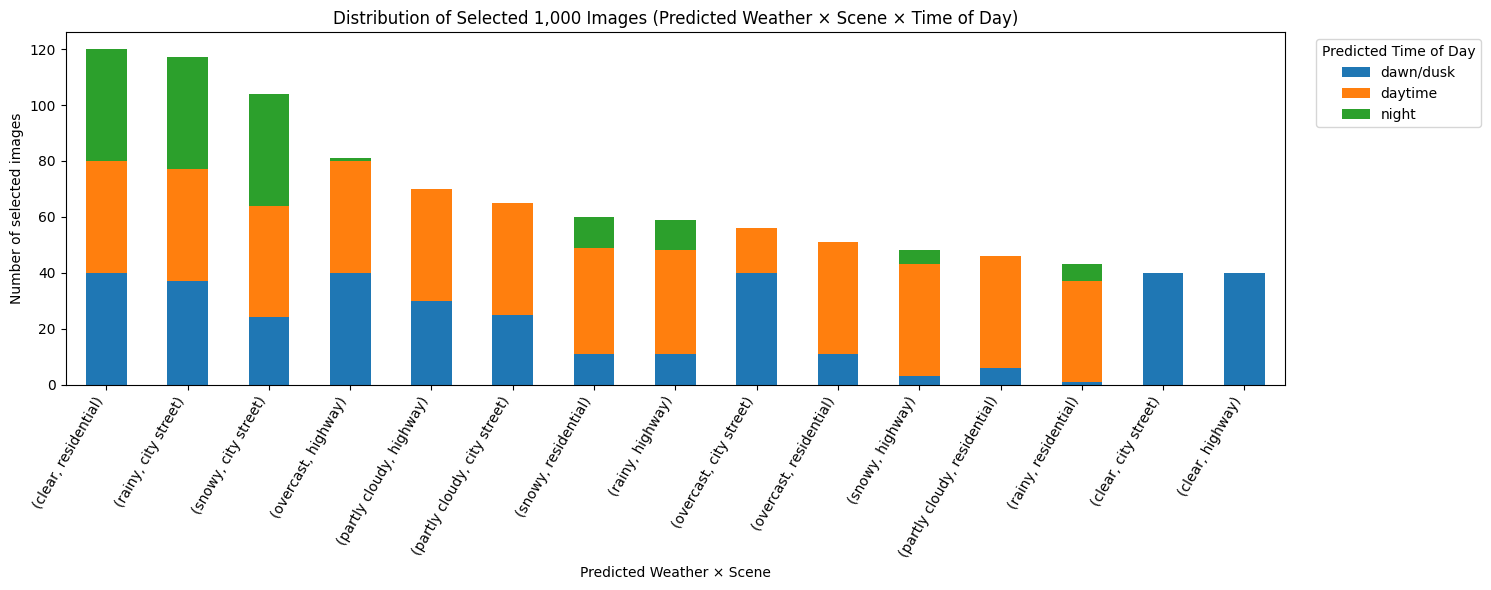

그래프 저장: /content/drive/MyDrive/AUE8088_PA2/level5_picks_distribution.png
총 이미지: 1000
Weather × Scene 조합 수: 15


In [13]:
# Level 5 picks의 pseudo-label 조합 분포 시각화
import os
import pandas as pd
import matplotlib.pyplot as plt

rows = []

for p in picks:
    weather_id = p["pseudo_weather"]
    scene_id = p["pseudo_scene"]
    time_id = p["pseudo_timeofday"]

    rows.append({
        "weather": CLASS_NAMES["weather"][weather_id],
        "scene": CLASS_NAMES["scene"][scene_id],
        "timeofday": CLASS_NAMES["timeofday"][time_id],
    })

picks_df = pd.DataFrame(rows)

# Weather × Scene을 행으로, Time of Day를 누적 막대로 표현
distribution = pd.crosstab(
    [
        picks_df["weather"],
        picks_df["scene"],
    ],
    picks_df["timeofday"],
)

# 빈도가 높은 조합부터 정렬
distribution = distribution.loc[
    distribution.sum(axis=1).sort_values(
        ascending=False
    ).index
]

# 그래프
ax = distribution.plot(
    kind="bar",
    stacked=True,
    figsize=(15, 6),
)

ax.set_title(
    "Distribution of Selected 1,000 Images "
    "(Predicted Weather × Scene × Time of Day)"
)
ax.set_xlabel("Predicted Weather × Scene")
ax.set_ylabel("Number of selected images")
ax.legend(
    title="Predicted Time of Day",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.xticks(
    rotation=60,
    ha="right",
)
plt.tight_layout()

save_path = (
    "/content/drive/MyDrive/AUE8088_PA2/"
    "level5_picks_distribution.png"
)

plt.savefig(
    save_path,
    dpi=200,
    bbox_inches="tight",
)
plt.show()

print("그래프 저장:", save_path)
print("총 이미지:", distribution.values.sum())
print("Weather × Scene 조합 수:", len(distribution))

## Curation Report — 필수

Final PPT 에 다음을 포함하세요.
- **선별 알고리즘** (의사코드 또는 1페이지 다이어그램).
- 본인 picks 1,000장의 **분포** — (예측된) weather × scene × timeofday — 를 heatmap 또는 stacked bar 로 시각화.
- **Random-1000 baseline** 결과와 본인의 **DI score** 비교.
- **Ablation**: 250 / 500 / 1000 장을 골랐을 때의 변화 — 추가 데이터의 한계 효용이 보이는지 확인.

여러 전략을 시험했다면 wandb 의 같은 프로젝트에 `STRATEGY_NAME` 만 바꿔서 별도 Run 으로 누적하세요. 학습 곡선·분포·DI score 비교가 한 페이지에 모입니다.